# Autocorrelación Espacial: Moran's I y LISA

## Introducción

**Qué se busca:** este notebook aplica la metodología de autocorrelación
espacial de `07_MatrizCorrelacion` (Moran's I global y LISA) a dos fuentes de
datos ya construidas en trabajos anteriores de este proyecto, en vez de
generar datos nuevos:

- **Parte A:** los 491 polígonos de altiplano ya tipificados
  (`02_clustering_espacial_altiplanos.py`). Pregunta: *¿los altiplanos con
  perfil morfométrico similar (altitud, pendiente, relieve) están
  geográficamente agrupados, o el patrón es esencialmente aleatorio en el
  espacio?*
- **Parte B:** los residuos del modelo de regresión logística NO
  espacializada sobre píxeles (`03_regresion_no_espacial_raster.ipynb`).
  Pregunta: *¿el modelo deja patrón espacial sin explicar en sus errores?
  Si lo deja, seria evidencia a favor de pasar a un modelo espacial en el
  futuro (siguiendo la logica de `09_SpatialRegression` del libro).*

**Método del libro utilizado:** notebook `07_MatrizCorrelacion` -- matriz de
pesos espaciales (KNN), Índice de Moran global, Gráfico de Moran, e
Indicadores Locales de Asociación Espacial (LISA / `esda.Moran_Local`).

**Backups generados:** al final de cada parte se exporta una capa GeoPackage
con todas las estadísticas calculadas (Moran local, cuadrante, significancia)
ya unidas a la geometría, para poder reabrir y re-estilizar cualquier figura
sin tener que re-ejecutar el notebook completo.


## [0] Configuración e importación de librerías

In [1]:
import time
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.warp import reproject, Resampling

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns

from libpysal.weights import KNN
import esda
from splot.esda import plot_moran, lisa_cluster, moran_scatterplot

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

warnings.filterwarnings("ignore")

CARPETA_RASTER = r"C:\Users\MSI\Desktop\Universidad\Analisis_Geoespacial\Raster\50m_UTM\Analisis"
CARPETA_CAPAS = r"C:\Users\MSI\Desktop\Universidad\Analisis_Geoespacial\Capas"
CARPETA_RESULTADOS = r"C:\Users\MSI\Desktop\Universidad\Analisis_Geoespacial\Resultados"

SEMILLA = 42


# PARTE A -- Autocorrelación espacial de los 491 altiplanos

## [A1] Cargar la capa ya tipificada

Se reutiliza directamente el GeoPackage exportado por
`02_clustering_espacial_altiplanos.py` (`altiplanos_clustering_espacial.gpkg`),
que ya trae las variables morfométricas junto con las etiquetas de cluster.
No hace falta corregir ninguna codificación de columnas: al exportarlo como
GeoPackage (a diferencia del `.dbf` de un shapefile) los nombres con tilde
(`Geología`, `Área`) se guardan y se leen correctamente.


In [2]:
gdf = gpd.read_file(f"{CARPETA_RESULTADOS}\\altiplanos_clustering_espacial.gpkg")
print(f"Poligonos cargados: {len(gdf)}")
print(f"Columnas: {list(gdf.columns)}")


Poligonos cargados: 491
Columnas: ['Altitud_X', 'Altitud_St', 'Relieve_X', 'Relieve_St', 'Pend_X', 'Pend_St', 'Num', 'Alt_90', 'Alt_50', 'Alt_10', 'Geo_Value', 'Geología', 'Área', 'Rel_90', 'Rel_50', 'Rel_10', 'Slp_90', 'Slp_50', 'Slp_10', 'Latitud', 'Lat_Max', 'Lat_Min', 'Longitud', 'Lon_Max', 'Lon_Min', 'cluster_mejor_knn', 'cluster_mejor_distancia', 'cluster_espacial', 'cluster_sin_restriccion', 'geometry']


## [A2] Matriz de pesos espaciales (KNN)

**Qué se busca:** construir la vecindad entre los 491 centroides. Igual que
en `02_clustering_espacial_altiplanos.py`, no se puede usar contigüidad tipo
Queen/Rook porque los poligonos no se tocan entre si. Se usa KNN con **k=6**,
el mismo valor que usa el libro en su propio ejemplo de cuencas colombianas
para esta sección (`weights.KNN.from_dataframe(cat, k=6)`), en vez de buscar
un k "óptimo" (esa búsqueda ya se hizo para clustering en el script 02; aquí
el objetivo es un diagnóstico de autocorrelación, no una optimización de
particiones).


In [3]:
w = KNN.from_dataframe(gdf, k=6)
w.transform = "r"
print(f"Matriz de pesos KNN(k=6) construida sobre {len(gdf)} centroides.")


Matriz de pesos KNN(k=6) construida sobre 491 centroides.


## [A3] Índice de Moran global

**Qué se busca:** un único número por variable que resuma qué tan agrupados
(vs. aleatorios) están sus valores en el espacio. Se calcula para las tres
variables morfométricas principales.

**Ventajas / desventajas del Índice de Moran global:**
- (+) Resume todo el mapa en un solo número comparable entre variables.
- (-) No dice **dónde** están los agrupamientos (para eso se necesita LISA,
  paso [A4]); tampoco distingue si el agrupamiento es de valores altos o
  bajos, solo que "valores similares están cerca".


In [4]:
variables_moran = ["Altitud_X", "Pend_X", "Relieve_X"]
resultados_moran = {}

np.random.seed(SEMILLA)  # esda.Moran no acepta seed directamente; se fija la semilla global antes
for var in variables_moran:
    mi = esda.Moran(gdf[var], w, permutations=999)
    resultados_moran[var] = mi
    print(f"{var}: I={mi.I:.4f}  p_sim={mi.p_sim:.4f}  z={mi.z_sim:.2f}")


Altitud_X: I=0.9200  p_sim=0.0010  z=37.93
Pend_X: I=0.5893  p_sim=0.0010  z=24.07
Relieve_X: I=0.4841  p_sim=0.0010  z=19.47


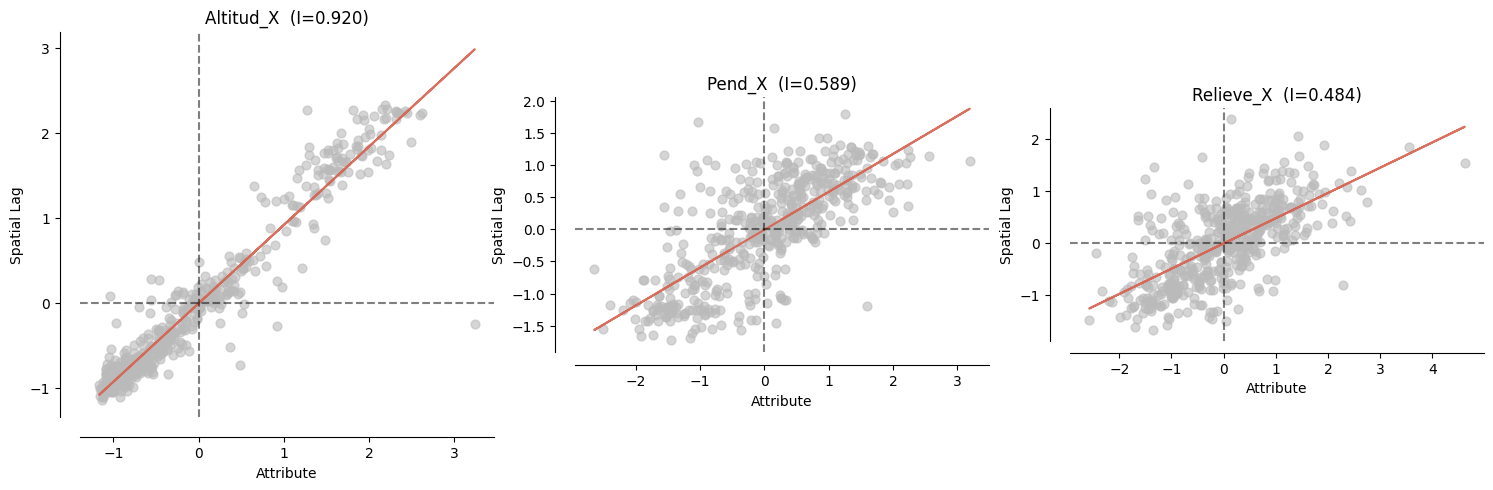

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, var in zip(axes, variables_moran):
    moran_scatterplot(resultados_moran[var], ax=ax)
    ax.set_title(f"{var}  (I={resultados_moran[var].I:.3f})")
plt.tight_layout()
plt.savefig(f"{CARPETA_RESULTADOS}\\15_moran_scatterplot_poligonos.png", dpi=150)
plt.show()


**Interpretación:** los tres valores de Moran's I son altos y
estadísticamente significativos (p=0.001 con 999 permutaciones), lo que
indica que los altiplanos NO se distribuyen al azar respecto a su morfometría:
altiplanos con altitud/pendiente/relieve similar tienden a estar geográficamente
cerca unos de otros -- una señal consistente con que distintas cadenas
montañosas o bloques tectónicos producen "familias" de altiplanos con un
perfil característico.


## [A4] LISA: ¿dónde están los agrupamientos?

**Qué se busca:** identificar qué altiplanos específicos forman parte de un
clúster local significativo (alto rodeado de altos, bajo rodeado de bajos) y
cuáles son valores atípicos espaciales, para la variable con el Moran's I
más alto (`Altitud_X`).


In [6]:
lisa = esda.Moran_Local(gdf["Altitud_X"], w, permutations=999, seed=SEMILLA)

gdf["Altitud_X_Is"] = lisa.Is
gdf["Altitud_X_quadrant"] = lisa.q
gdf["Altitud_X_p_sim"] = lisa.p_sim
gdf["Altitud_X_significativo"] = lisa.p_sim < 0.05

print("Distribucion de cuadrantes LISA (1=HH, 2=LH, 3=LL, 4=HL):")
print(pd.Series(lisa.q).value_counts().sort_index())
print(f"\nPoligonos con cluster local significativo (p<0.05): {gdf['Altitud_X_significativo'].sum()} de {len(gdf)}")


Distribucion de cuadrantes LISA (1=HH, 2=LH, 3=LL, 4=HL):
1    172
2     22
3    284
4     13
Name: count, dtype: int64

Poligonos con cluster local significativo (p<0.05): 284 de 491


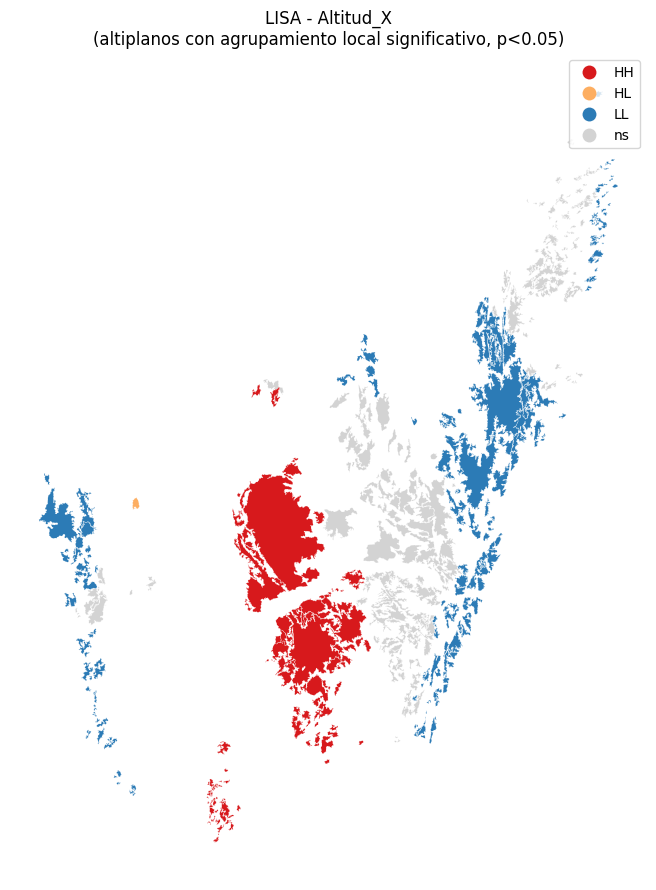

In [7]:
fig, ax = plt.subplots(1, figsize=(9, 9))
lisa_cluster(lisa, gdf, ax=ax)
ax.set_title("LISA - Altitud_X\n(altiplanos con agrupamiento local significativo, p<0.05)")
plt.tight_layout()
plt.savefig(f"{CARPETA_RESULTADOS}\\16_lisa_cluster_altitud_poligonos.png", dpi=150)
plt.show()


## [A5] Exportar capa de respaldo (Parte A)

Se guarda el GeoDataFrame con las columnas de Moran local ya calculadas, para
poder reabrir esta capa directamente en QGIS/ArcGIS o en Python y regenerar
el mapa (cambiar colores, título, etc.) sin tener que reconstruir la matriz de
pesos ni recalcular LISA.


In [8]:
ruta_backup_a = f"{CARPETA_RESULTADOS}\\altiplanos_moran_lisa.gpkg"
gdf.to_file(ruta_backup_a, driver="GPKG")
print(f"Backup Parte A guardado en: {ruta_backup_a}")


Backup Parte A guardado en: C:\Users\MSI\Desktop\Universidad\Analisis_Geoespacial\Resultados\altiplanos_moran_lisa.gpkg


# PARTE B -- Diagnóstico espacial de los residuos del modelo raster

## [B1] Recrear la muestra de píxeles y el modelo (idéntico a `03_regresion_no_espacial_raster.ipynb`)

**Qué se busca:** reconstruir exactamente la misma muestra de 300,000
píxeles y el mismo modelo de regresión logística del notebook anterior
(misma `SEMILLA=42`), para poder calcular sus residuos. No se guardó la
muestra ni los residuos como archivo en el notebook anterior, así que se
recalculan aquí desde las capas ráster originales; el resultado es
reproducible porque se usa la misma semilla aleatoria.


In [9]:
t0 = time.time()

with rasterio.open(f"{CARPETA_RASTER}\\DEM_NA_50.tif") as src:
    altitud = src.read(1).astype(np.float32)
    dem_nodata = src.nodata
    ref_transform = src.transform
    ref_crs = src.crs
    ref_shape = (src.height, src.width)
mascara_dem_valida = altitud != dem_nodata

with rasterio.open(f"{CARPETA_RASTER}\\Altiplanos.tif") as src:
    altiplano_original = src.read(1)
    altiplano_nodata = src.nodata
    altiplano_transform = src.transform
    altiplano_crs = src.crs

altiplano_alineado = np.zeros(ref_shape, dtype=np.uint8)
reproject(
    source=altiplano_original, destination=altiplano_alineado,
    src_transform=altiplano_transform, src_crs=altiplano_crs,
    dst_transform=ref_transform, dst_crs=ref_crs,
    resampling=Resampling.nearest, src_nodata=altiplano_nodata, dst_nodata=0,
)

predictores_archivos = {
    "Altitud": "DEM_NA_50.tif", "Pendiente": "Slp_NA_50.tif", "Relieve_5": "Rel_NA_5.tif",
    "ResidMedia_5": "Resta_Alt_NA_Alt_mean_5.tif", "ResidMedia_10": "Resta_Alt_NA_Alt_mean_10.tif",
    "ResidMin_3": "Resta_Alt_NA_Alt_min_3.tif", "ResidMin_10": "Resta_Alt_NA_Alt_min_10.tif",
    "ResidMin_50": "Resta_Alt_NA_Alt_min_50.tif", "ResidMin_100": "Resta_Alt_NA_Alt_min_100.tif",
    "ResidMax_3": "Resta_Alt_max_3_Alt_NA.tif", "ResidMax_10": "Resta_Alt_max_10_Alt_NA.tif",
    "ResidMax_50": "Resta_Alt_max_50_Alt_NA.tif", "ResidMax_100": "Resta_Alt_max_100_Alt_NA.tif",
    "DifMedia_3_10": "Resta_Alt_mean_3_10.tif",
    "PendResidMedia_5": "Slp_Resta_Alt_NA_Alt_mean_5.tif", "PendResidMedia_10": "Slp_Resta_Alt_NA_Alt_mean_10.tif",
    "PendDifMedia_3_10": "Slp_Resta_Alt_mean_3_10.tif", "PendDifMedia_5_10": "Slp_Resta_Alt_mean_5_10.tif",
}

datos = {}
mascara_valida = mascara_dem_valida.copy()
for nombre, archivo in predictores_archivos.items():
    with rasterio.open(f"{CARPETA_RASTER}\\{archivo}") as src:
        banda = src.read(1).astype(np.float32)
        nod = src.nodata
        if nod is not None and np.isnan(nod):
            valido_capa = ~np.isnan(banda)
        elif nod is not None:
            valido_capa = banda != nod
        else:
            valido_capa = np.ones_like(banda, dtype=bool)
    datos[nombre] = banda
    mascara_valida &= valido_capa

idx_validos = np.flatnonzero(mascara_valida)
variables_predictoras = list(predictores_archivos.keys())

tabla = pd.DataFrame({nombre: banda.ravel()[idx_validos] for nombre, banda in datos.items()})
y_altiplano = (altiplano_alineado == 1) & mascara_valida
tabla["Altiplano"] = y_altiplano.ravel()[idx_validos].astype(int)

# Coordenadas reales (X, Y) de cada pixel valido, necesarias para la
# matriz de pesos espaciales del diagnostico (KNN sobre puntos)
filas, columnas = np.unravel_index(idx_validos, ref_shape)
xs, ys = rasterio.transform.xy(ref_transform, filas, columnas)
tabla["X"] = np.array(xs)
tabla["Y"] = np.array(ys)

print(f"Tabla de pixeles reconstruida: {tabla.shape}  t={time.time()-t0:.1f}s")


Tabla de pixeles reconstruida: (24783966, 21)  t=8.9s


In [10]:
N_MUESTRA = 300_000
muestra = tabla.sample(n=N_MUESTRA, random_state=SEMILLA)
X = muestra[variables_predictoras]
y = muestra["Altiplano"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=SEMILLA, stratify=y
)
escalador = StandardScaler()
X_train_s = escalador.fit_transform(X_train)

modelo = LogisticRegression(max_iter=1000)
modelo.fit(X_train_s, y_train)

print(f"Modelo reajustado sobre {len(X_train):,} filas de entrenamiento (identico a 03_regresion_no_espacial_raster.ipynb).")


Modelo reajustado sobre 210,000 filas de entrenamiento (identico a 03_regresion_no_espacial_raster.ipynb).


## [B2] Calcular los residuos

**Qué se busca:** el libro (`09_SpatialRegression`) diagnostica autocorrelación
espacial sobre los residuos de un modelo OLS (`m1.u`). La regresión logística
no tiene un residuo "OLS" nativo; se usa en su lugar el **residuo de
respuesta** (`y - probabilidad predicha`), el análogo más directo: positivo
donde el modelo SUBestima la probabilidad de ser altiplano, negativo donde la
SOBREestima.


In [11]:
X_muestra_s = escalador.transform(X)
prob_muestra = modelo.predict_proba(X_muestra_s)[:, 1]
residuo = y.values - prob_muestra

muestra = muestra.copy()
muestra["prob_predicha"] = prob_muestra
muestra["residuo"] = residuo

print(f"Residuo: media={residuo.mean():.4f}  desv.est.={residuo.std():.4f}")
print(f"Rango: [{residuo.min():.3f}, {residuo.max():.3f}]")


Residuo: media=-0.0002  desv.est.=0.2449
Rango: [-0.990, 1.000]


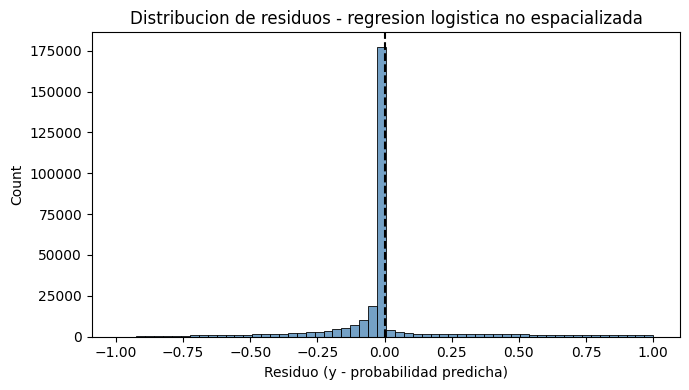

In [12]:
plt.figure(figsize=(7, 4))
sns.histplot(residuo, bins=60, color="steelblue")
plt.axvline(0, color="k", linestyle="--")
plt.xlabel("Residuo (y - probabilidad predicha)")
plt.title("Distribucion de residuos - regresion logistica no espacializada")
plt.tight_layout()
plt.show()


## [B3] Matriz de pesos espaciales sobre la muestra de píxeles

**Qué se busca:** construir una vecindad KNN entre los 300,000 puntos-píxel
de la muestra, usando sus coordenadas reales (no la geometría de polígono,
ya que aquí cada observación es un punto). Se usa `KNN.from_array` (en vez de
`KNN.from_dataframe`) porque se trabaja con un arreglo de coordenadas X, Y
en vez de un GeoDataFrame.

**Nota sobre el tamaño de la muestra:** en una prueba preliminar, el valor de
Moran's I aumentó con el tamaño de la muestra (0.29 con 10,000 puntos hasta
0.61 con 300,000), porque con más puntos los vecinos "k más cercanos" quedan
a una distancia real menor (vecindad mas genuinamente local). Por eso se usa
aquí la muestra completa de 300,000 en vez de un subconjunto más pequeño,
para obtener la estimación más representativa posible sin necesidad de
recorrer los 25 millones de píxeles totales.


In [13]:
t1 = time.time()
coords_muestra = muestra[["X", "Y"]].values
w_pixeles = KNN.from_array(coords_muestra, k=8)
w_pixeles.transform = "r"
print(f"Matriz de pesos KNN(k=8) construida sobre {len(muestra):,} pixeles en {time.time()-t1:.1f}s")


Matriz de pesos KNN(k=8) construida sobre 300,000 pixeles en 3.8s


## [B4] Índice de Moran global de los residuos

**Qué se busca:** responder la pregunta central de esta parte: ¿los errores
del modelo tienen estructura espacial, o son esencialmente ruido aleatorio
sin patrón geográfico?


In [14]:
np.random.seed(SEMILLA)  # esda.Moran no acepta seed directamente; se fija la semilla global antes
t1 = time.time()
mi_residuo = esda.Moran(muestra["residuo"], w_pixeles, permutations=999)
print(f"Moran's I de los residuos: I={mi_residuo.I:.4f}  p_sim={mi_residuo.p_sim:.4f}  z={mi_residuo.z_sim:.2f}")
print(f"(calculado en {time.time()-t1:.1f}s)")


Moran's I de los residuos: I=0.6101  p_sim=0.0010  z=676.43
(calculado en 14.4s)


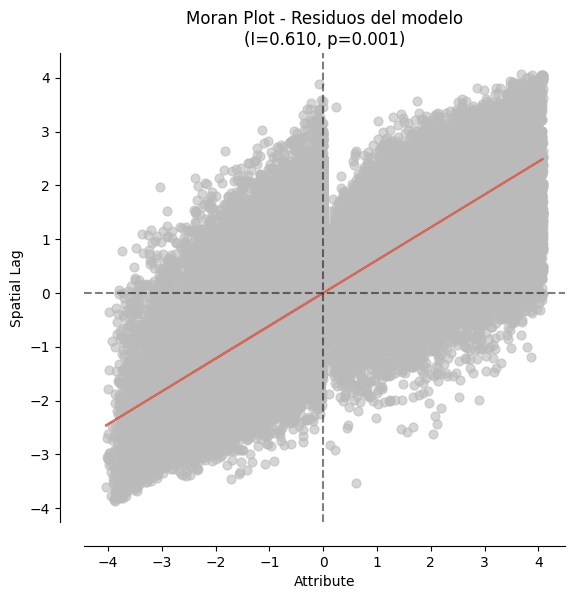

In [15]:
fig, ax = plt.subplots(figsize=(6, 6))
moran_scatterplot(mi_residuo, ax=ax)
ax.set_title(f"Moran Plot - Residuos del modelo\n(I={mi_residuo.I:.3f}, p={mi_residuo.p_sim:.3f})")
plt.tight_layout()
plt.savefig(f"{CARPETA_RESULTADOS}\\17_moran_scatterplot_residuos_raster.png", dpi=150)
plt.show()


**Interpretación:** un Moran's I positivo y significativo en los
residuos confirma que el modelo NO espacializado **deja patrón espacial sin
explicar**: los píxeles donde el modelo se equivoca (sub o sobreestima) no
están distribuidos al azar, sino agrupados geográficamente. Esto es
exactamente el diagnóstico que el libro (`09_SpatialRegression`) usa para
justificar el paso hacia modelos espaciales explícitos (SAR/SEM,
`10_SAR`) -- aquí se documenta el diagnóstico, dejando el ajuste de un
modelo espacial completo sobre el ráster (computacionalmente mucho más
exigente a esta escala) como trabajo futuro.


## [B5] LISA de los residuos: ¿dónde falla más el modelo?

**Qué se busca:** mapear específicamente las zonas de sub-estimación
(hot spots de error positivo) y sobre-estimación (cold spots) sistemática,
para identificar en qué parte del área de estudio el modelo no espacializado
es menos confiable.


In [16]:
t1 = time.time()
lisa_residuo = esda.Moran_Local(muestra["residuo"].values, w_pixeles, permutations=199, seed=SEMILLA, n_jobs=-1)
print(f"LISA de residuos calculado en {time.time()-t1:.1f}s")

muestra["residuo_Is"] = lisa_residuo.Is
muestra["residuo_quadrant"] = lisa_residuo.q
muestra["residuo_p_sim"] = lisa_residuo.p_sim
muestra["residuo_significativo"] = lisa_residuo.p_sim < 0.05

print(f"\nPixeles con residuo local significativo (p<0.05): {muestra['residuo_significativo'].sum():,} de {len(muestra):,}")


LISA de residuos calculado en 338.0s

Pixeles con residuo local significativo (p<0.05): 75,854 de 300,000


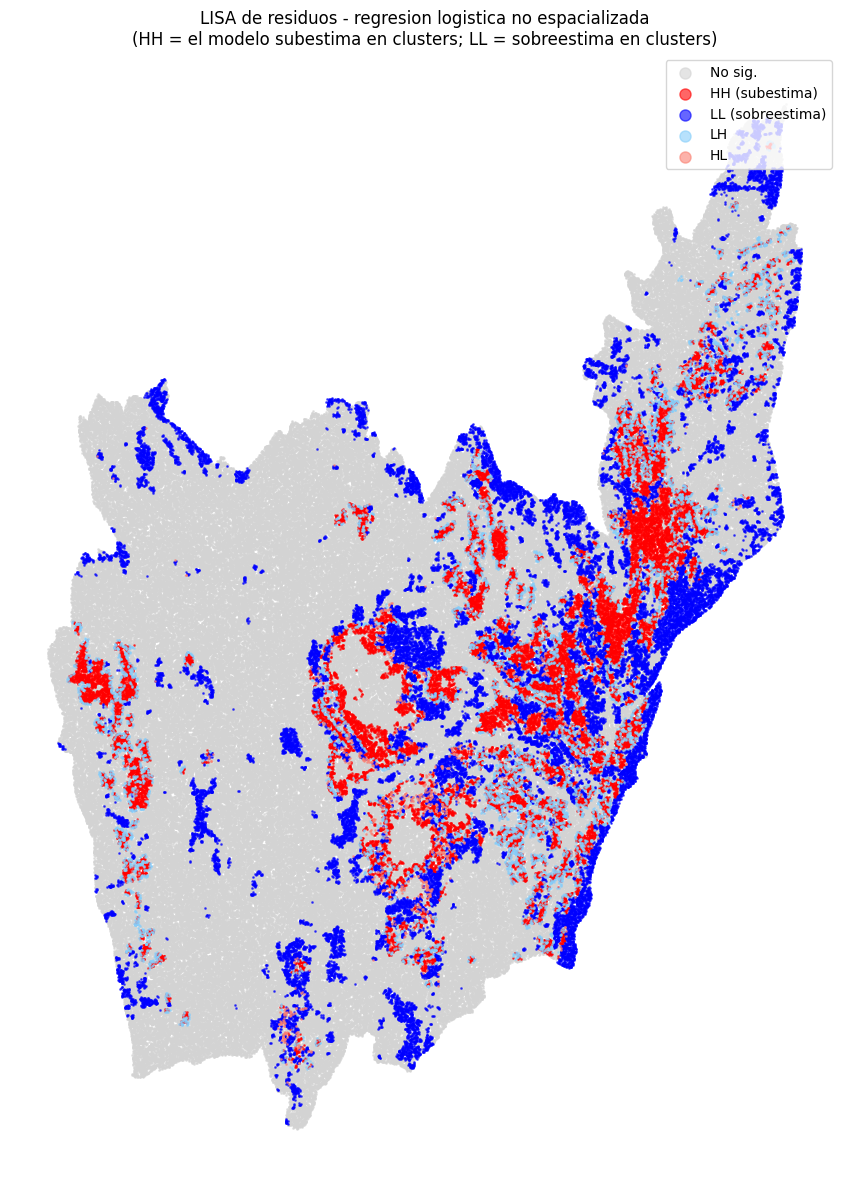

In [17]:
sig = muestra["residuo_significativo"].values
quad = muestra["residuo_quadrant"].values
# Igual que en 07_MatrizCorrelacion: 1=HH (subestimacion agrupada), 3=LL (sobreestimacion agrupada)
etiqueta = np.where(~sig, "No sig.", np.where(quad == 1, "HH (subestima)",
             np.where(quad == 3, "LL (sobreestima)", np.where(quad == 2, "LH", "HL"))))

colores = {"No sig.": "lightgrey", "HH (subestima)": "red", "LL (sobreestima)": "blue",
           "LH": "lightskyblue", "HL": "salmon"}

fig, ax = plt.subplots(figsize=(10, 12))
for categoria, color in colores.items():
    mask_cat = etiqueta == categoria
    ax.scatter(muestra["X"].values[mask_cat], muestra["Y"].values[mask_cat],
               s=1, c=color, label=categoria, alpha=0.6)
ax.set_title("LISA de residuos - regresion logistica no espacializada\n"
             "(HH = el modelo subestima en clusters; LL = sobreestima en clusters)")
ax.set_axis_off()
ax.set_aspect("equal")
leg = ax.legend(markerscale=8, loc="upper right")
plt.tight_layout()
plt.savefig(f"{CARPETA_RESULTADOS}\\18_lisa_residuos_raster.png", dpi=150)
plt.show()


## [B6] Exportar capa de respaldo (Parte B)

Se guarda la muestra de 300,000 píxeles (convertida a puntos) con el residuo,
la probabilidad predicha y las estadísticas LISA, como GeoPackage. Al ser
puntos (no una grilla completa), permite reabrir y re-estilizar el mapa de
residuos en QGIS/ArcGIS o Python sin repetir el ajuste del modelo ni el
cálculo de la matriz de pesos.


In [18]:
geometria_puntos = gpd.points_from_xy(muestra["X"], muestra["Y"])
gdf_residuos = gpd.GeoDataFrame(
    muestra.drop(columns=["X", "Y"]), geometry=geometria_puntos, crs=ref_crs
)

ruta_backup_b = f"{CARPETA_RESULTADOS}\\residuos_raster_lisa_muestra.gpkg"
gdf_residuos.to_file(ruta_backup_b, driver="GPKG")
print(f"Backup Parte B guardado en: {ruta_backup_b}  ({len(gdf_residuos):,} puntos)")
print(f"\nTIEMPO TOTAL DEL NOTEBOOK: {time.time()-t0:.1f}s")


Backup Parte B guardado en: C:\Users\MSI\Desktop\Universidad\Analisis_Geoespacial\Resultados\residuos_raster_lisa_muestra.gpkg  (300,000 puntos)

TIEMPO TOTAL DEL NOTEBOOK: 375.0s


## Conclusiones

- **Parte A:** los 491 altiplanos muestran autocorrelación espacial fuerte y
  significativa en su morfometría (Moran's I de 0.48 a 0.92 según la
  variable), y el análisis LISA identifica más de la mitad de los polígonos
  como parte de un clúster local significativo de tipo HH o LL. Esto refuerza
  el hallazgo del trabajo de clustering: los "tipos" de altiplano no están
  distribuidos al azar en el territorio.
- **Parte B:** los residuos del modelo de regresión logística NO
  espacializado muestran autocorrelación espacial positiva y significativa,
  confirmando que el modelo actual deja estructura geográfica sin explicar.
  Esto **no invalida** las métricas de predicción ya reportadas (AUC=0.95),
  pero sí motiva, como trabajo futuro, evaluar si un modelo espacial (o
  simplemente agregar coordenadas/variables de vecindad como predictores)
  mejora el ajuste.
